# Display final assignment — battery results

Notebook leggero per visualizzare **solo l'assegnamento finale** prodotto dal
binario Rust `nshift`, a partire dai risultati di una batteria di test generata
da `run_battery.py` (config tipo `battery_config.json`).

Differenze rispetto a `nshift_assignment_analysis.ipynb`:

- nessuna animazione per-run/per-batch (niente `plot_solver_execution_stacked`):
  viene mostrato solo lo stato finale degli assegnamenti, come scatter timeline
  e/o stacked bar per slot;
- non legge un `config.json` di run singola (qui non esiste, essendo i dati
  prodotti da una batteria intera): la cartella dati va indicata esplicitamente
  sotto tramite `RUN_DIR`, nel formato prodotto da `run_battery.py`, cioè
  `results/<scenario_id>/rust_<mode>/`, ad es.
  `tests/battery/results/low_load_2028/rust_relaxed_retry`.

Presuppone backend **rust** (cerca `summary_by_n.csv` e `N<k>/per_request.csv`
dentro `RUN_DIR`, come scritti dal binario `nshift`).

Imposta `RUN_DIR` e `SELECTED_N` nella cella sotto ed esegui tutte le celle.

In [37]:
%matplotlib inline
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.dpi'] = 120
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

# --- user options ---
# Path to the per-scenario / per-mode results folder produced by run_battery.py.
# This is the directory that contains `summary_by_n.csv` and the `N<k>/`
# subfolders (per_request.csv, etc.), e.g.
#   "tests/battery/results/xhigh_load_120/rust_relaxed_retry"
# May be given as an absolute path, or as a path relative to the carbonshift
# package root (the folder that contains `online2/`, `rust/`, `tests/`, ...).
RUN_DIR = "tests/battery/results/xhigh_load_120/rust_relaxed_retry"

SELECTED_N = 6  # batch_size (N) to visualize

# Final assignment highlight plot mode: "scatter" | "stacked" | "both"
TIMELINE_HIGHLIGHT_PLOT_MODE = "both"

# Group size, in slots, for the aggregate carbon-cost labels on stacked plots.
CARBON_COST_GROUP_SIZE = 12


In [38]:
# Locate the carbonshift package root (the directory containing `online2/`)
# by walking up from the notebook's working directory — the same root that
# run_battery.py calls CARBONSHIFT_ROOT. This notebook lives in
# `tests/battery/`, a sibling of `online2/`, rather than inside
# `online2/notebooks/` like the original analysis notebook, so we search
# upward instead of assuming a fixed number of parent levels.

def _find_carbonshift_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "online2" / "tests" / "Nshift_speed").exists():
            return candidate
    raise FileNotFoundError(
        "Cannot locate the carbonshift root (a directory containing "
        f"'online2/tests/Nshift_speed') starting from {start}. Run this "
        "notebook from within the carbonshift repo (e.g. tests/battery/), "
        "or set CARBONSHIFT_ROOT manually below."
    )

CARBONSHIFT_ROOT = _find_carbonshift_root(Path.cwd().resolve())
ONLINE2_ROOT = CARBONSHIFT_ROOT / "online2"
notebooks_dir = ONLINE2_ROOT / "notebooks"

for p in (str(ONLINE2_ROOT), str(notebooks_dir)):
    if p not in sys.path:
        sys.path.insert(0, p)

# Reuse the same flavour colors / dataframe-prep helpers as
# nshift_assignment_analysis.ipynb, so the final-assignment plots match it
# in style.
from nb_utils import (
    FLAVOUR_COLORS,
    bool_series as _bool_series,
    resolve_plot_mode as _resolve_plot_mode,
    prepare_local as _prepare_timeline,
    flavour_order as _flavour_order,
)

print(f"CARBONSHIFT_ROOT = {CARBONSHIFT_ROOT}")

CARBONSHIFT_ROOT = /home/francis/unipi/carbonshift/carbonshift


In [39]:
# --- resolve the run directory and load data ---
run_dir = Path(RUN_DIR)
if not run_dir.is_absolute():
    run_dir = (CARBONSHIFT_ROOT / run_dir).resolve()
if not run_dir.exists():
    raise FileNotFoundError(f"Run directory not found: {run_dir}")

# `run_dir` is expected to look like .../results/<scenario_id>/rust_<mode>/
scenario_id = run_dir.parent.name
mode_dir_name = run_dir.name
mode_label = mode_dir_name[len("rust_"):] if mode_dir_name.startswith("rust_") else mode_dir_name

n_dir = run_dir / f"N{int(SELECTED_N)}"
per_request_path = n_dir / "per_request.csv"
if not per_request_path.exists():
    raise FileNotFoundError(
        f"Missing per_request.csv for N={SELECTED_N}: {per_request_path}\n"
        f"Available N folders in {run_dir}: {sorted(p.name for p in run_dir.glob('N*'))}"
    )

per_request = pd.read_csv(per_request_path)

summary_path = run_dir / "summary_by_n.csv"
if summary_path.exists():
    summary_df = pd.read_csv(summary_path)
    summary_df["batch_size"] = pd.to_numeric(summary_df["batch_size"], errors="coerce")
    run_summary = summary_df[summary_df["batch_size"] == int(SELECTED_N)]
else:
    print(f"WARNING: {summary_path} not found; skipping summary display.")
    run_summary = pd.DataFrame()

# Battery runs keep a copy of the generated scenario one level above each mode
# directory. Load it here so plots can use the real carbon forecast and capacity
# tiers, instead of notebook-local defaults.
scenario_suffix = scenario_id.split("_")[-1]
preferred_scenario_path = run_dir.parent / f"scenario_seed_{scenario_suffix}.json"
scenario_candidates = [preferred_scenario_path] if preferred_scenario_path.exists() else sorted(run_dir.parent.glob("scenario*.json"))
scenario_path = scenario_candidates[0] if scenario_candidates else None
if scenario_path is not None:
    scenario = json.loads(scenario_path.read_text(encoding="utf-8"))
else:
    print(f"WARNING: no scenario*.json found in {run_dir.parent}; carbon forecast and capacity tiers unavailable.")
    scenario = {}

scenario_meta = scenario.get("metadata", {})
carbon_forecast = [float(v) for v in scenario.get("carbon_forecast", [])]
capacity_tiers = list(scenario_meta.get("capacity_tiers", []))
total_slots = int(
    scenario_meta.get(
        "total_slots",
        max(int(pd.to_numeric(per_request["scheduled_slot"], errors="coerce").max()) + 1, len(carbon_forecast))
        if "scheduled_slot" in per_request.columns and not per_request.empty
        else len(carbon_forecast),
    )
)

print(f"Scenario: {scenario_id}   Mode: {mode_label}   N: {SELECTED_N}")
print(f"Loaded {len(per_request)} requests from {per_request_path}")
if scenario_path is not None:
    print(f"Loaded scenario from {scenario_path}")
if not run_summary.empty:
    display(run_summary.round(4))


Scenario: xhigh_load_120   Mode: relaxed_retry   N: 6
Loaded 8184 requests from /home/francis/unipi/carbonshift/carbonshift/tests/battery/results/xhigh_load_120/rust_relaxed_retry/N6/per_request.csv
Loaded scenario from /home/francis/unipi/carbonshift/carbonshift/tests/battery/results/xhigh_load_120/scenario_seed_120.json


,execution_mode,batch_size,realtime_slots,realtime_speed_scale,baseline_flavour_name,baseline_flavour_duration,baseline_flavour_error,requests_total,requests_scheduled,requests_unscheduled,batches_executed,total_carbon_cost,global_average_error,global_average_error_real,global_average_error_modeled,global_average_error_real_skip_first_k,global_average_error_modeled_skip_first_k,requests_assigned_with_greedy_fallback,requests_assigned_with_relaxed_retry,total_rollbacks,max_consecutive_rollbacks,requests_assigned_with_rollback,peak_concurrent_workers,avg_concurrent_workers,solver_time_ms_min,solver_time_ms_max,solver_time_ms_avg,queue_wait_seconds_min,queue_wait_seconds_max,queue_wait_seconds_avg,final_wait_seconds_min,final_wait_seconds_max,final_wait_seconds_avg,baseline_total_carbon_cost,carbon_cost_saving_vs_baseline,carbon_cost_saving_vs_baseline_pct
2,nshift_dp,6,True,0.05,NaN,0,0,8312,8184,128,1392,11697.0649,3.9489,3.9489,3.9489,0,0,0,1579,0,0,0,20,11.9109,0.0639,497.9893,50.3003,0,60,0.8859,0,80,26.9257,0,0,0


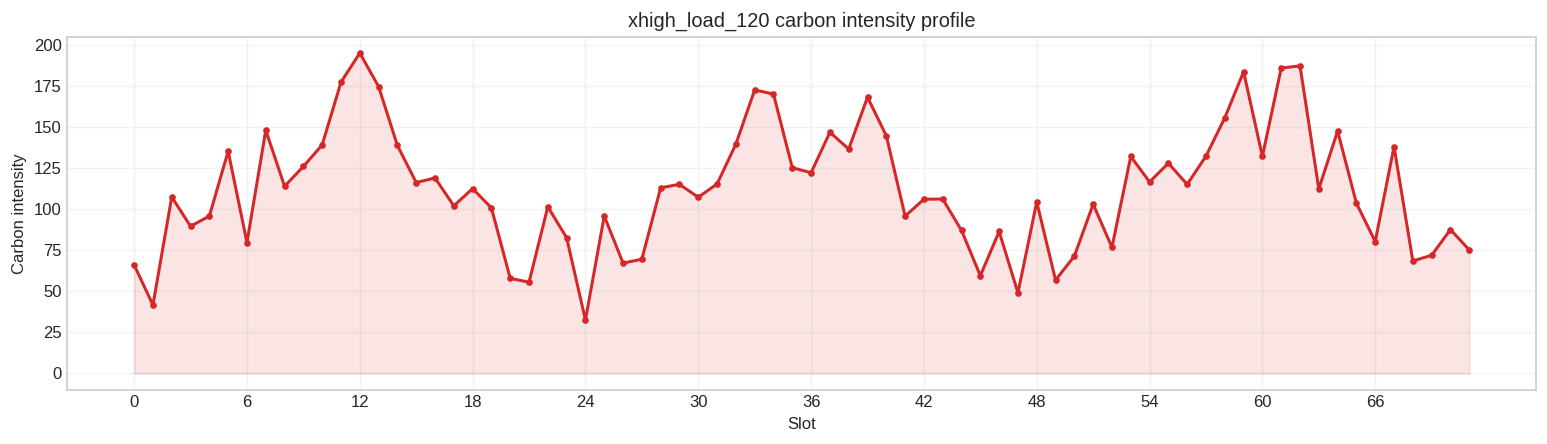

In [40]:
# --- carbon intensity profile for the selected scenario ---
def _plot_carbon_intensity(carbon_forecast, title):
    if not carbon_forecast:
        print("No carbon_forecast found in the scenario; skipping carbon intensity plot.")
        return

    intensities = pd.Series(carbon_forecast, dtype=float)
    slots = intensities.index.to_numpy()

    fig, ax = plt.subplots(figsize=(13, 3.8))
    ax.plot(slots, intensities.to_numpy(), marker="o", markersize=3, linewidth=1.8, color="#d62728")
    ax.fill_between(slots, intensities.to_numpy(), alpha=0.12, color="#d62728")
    ax.set_xlabel("Slot")
    ax.set_ylabel("Carbon intensity")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    tick_step = max(1, int(len(intensities)) // 12)
    ax.set_xticks(list(range(0, len(intensities), tick_step)))
    plt.tight_layout()


_plot_carbon_intensity(
    carbon_forecast,
    title=f"{scenario_id} carbon intensity profile",
)


In [56]:
# Same plotting helpers as the "final timeline" cell of
# nshift_assignment_analysis.ipynb, with battery-scenario overlays.

def _format_number(value):
    value = float(value)
    return f"{value:g}"


def _capacity_tier_rows():
    rows = []
    for tier in capacity_tiers:
        max_req = tier.get("max_requests") if isinstance(tier, dict) else None
        if max_req is None or pd.isna(max_req):
            continue
        try:
            max_req = float(max_req)
        except (TypeError, ValueError):
            continue
        rows.append(
            {
                "max_requests": max_req,
                "multiplier": tier.get("multiplier", "?") if isinstance(tier, dict) else "?",
            }
        )
    return rows


def _slot_carbon_costs(local, slots):
    if "carbon_cost" not in local.columns:
        return None
    carbon = local.copy()
    carbon["carbon_cost"] = pd.to_numeric(carbon["carbon_cost"], errors="coerce").fillna(0.0)
    return carbon.groupby("scheduled_slot")["carbon_cost"].sum().reindex(slots, fill_value=0.0)


def _carbon_cost_group_rows(carbon_costs, group_size):
    if carbon_costs is None:
        return []
    try:
        group_size = int(group_size)
    except (TypeError, ValueError):
        return []
    if group_size <= 0 or carbon_costs.empty:
        return []

    max_slot = int(max(carbon_costs.index))
    rows = []
    for start in range(0, max_slot + 1, group_size):
        end = min(start + group_size - 1, max_slot)
        group_slots = list(range(start, end + 1))
        total = float(carbon_costs.reindex(group_slots, fill_value=0.0).sum())
        rows.append(
            {
                "start": start,
                "end": end,
                "center": (start + end) / 2,
                "total": total,
            }
        )
    return rows


def _plot_scatter_timeline(local, flag_mask, title, dark_label):
    fig, ax = plt.subplots(figsize=(13, 4.8))
    x = local.index.to_numpy()
    y = local["scheduled_slot"].to_numpy()
    flags = flag_mask.to_numpy()

    ax.scatter(x[~flags], y[~flags], s=20, alpha=0.35, color="tab:blue", label="Other assignments")
    ax.scatter(x[flags], y[flags], s=30, alpha=0.95, color="black", label=dark_label)

    ax.set_xlabel("Assigned requests ordered by arrival_slot then request_id")
    ax.set_ylabel("Scheduled slot")
    ax.set_title(title)
    ax.legend(loc="best")
    ax.grid(alpha=0.2)
    plt.tight_layout()


def _plot_stacked_timeline(local, flag_mask, title, dark_label):
    fig, ax = plt.subplots(figsize=(13, 6.1))
    slots = sorted(local["scheduled_slot"].unique().tolist())
    if not slots:
        ax.set_title(f"{title} (no assignments)")
        ax.grid(alpha=0.2)
        plt.tight_layout()
        return

    bottom = pd.Series(0, index=slots, dtype=float)
    strategies = _flavour_order(local)
    for flavour in strategies:
        base_color = FLAVOUR_COLORS.get(flavour, "#7f7f7f")

        flavour_mask = local["flavour_name"] == flavour
        normal_counts = (
            local[flavour_mask & (~flag_mask)]
            .groupby("scheduled_slot")
            .size()
            .reindex(slots, fill_value=0)
        )
        highlighted_counts = (
            local[flavour_mask & flag_mask]
            .groupby("scheduled_slot")
            .size()
            .reindex(slots, fill_value=0)
        )

        if int(normal_counts.sum()) > 0:
            ax.bar(
                slots,
                normal_counts.values,
                bottom=bottom.values,
                color=base_color,
                alpha=0.5,
                edgecolor="white",
                linewidth=0.4,
                label=f"{flavour} (normal)",
            )
            bottom = bottom + normal_counts

        if int(highlighted_counts.sum()) > 0:
            ax.bar(
                slots,
                highlighted_counts.values,
                bottom=bottom.values,
                color=base_color,
                alpha=1.0,
                edgecolor="black",
                linewidth=0.6,
                label=f"{flavour} ({dark_label})",
            )
            bottom = bottom + highlighted_counts

    tier_rows = _capacity_tier_rows()
    for tier in tier_rows:
        max_req = tier["max_requests"]
        ax.axhline(y=max_req, linestyle="--", linewidth=0.85, alpha=0.45, color="gray")
        ax.text(
            max(slots) + 0.35,
            max_req,
            f"cap<={_format_number(max_req)} (x{tier['multiplier']})",
            fontsize=8,
            color="gray",
            va="bottom",
        )

    all_cost_slots = list(range(max(total_slots, max(slots) + 1)))
    carbon_costs = _slot_carbon_costs(local, slots)
    carbon_costs_for_groups = _slot_carbon_costs(local, all_cost_slots)
    carbon_group_rows = _carbon_cost_group_rows(carbon_costs_for_groups, CARBON_COST_GROUP_SIZE)

    max_bar_height = float(bottom.max()) if len(bottom) else 0.0
    max_tier_height = max([tier["max_requests"] for tier in tier_rows], default=0.0)
    plot_top = max(max_bar_height, max_tier_height, 1.0)
    label_offset = max(0.35, plot_top * 0.02)
    group_label_y = plot_top + max(1.2, plot_top * 0.16)

    if carbon_costs is not None:
        for slot, value in carbon_costs.items():
            ax.text(
                slot,
                float(bottom.loc[slot]) + label_offset,
                f"{float(value):.2f}",
                rotation=90,
                ha="center",
                va="bottom",
                fontsize=7,
                color="#333333",
                clip_on=False,
            )

    if carbon_group_rows:
        for row in carbon_group_rows:
            if row["start"] > min(slots):
                ax.axvline(row["start"] - 0.5, color="#d62728", alpha=0.16, linewidth=0.8)
            ax.text(
                row["center"],
                group_label_y,
                f"{row['start']}-{row['end']}: {row['total']:.1f} gCO2",
                ha="center",
                va="center",
                fontsize=8,
                color="#7f1d1d",
                bbox={"facecolor": "white", "edgecolor": "#d62728", "alpha": 0.78, "pad": 2.0},
                clip_on=False,
            )

    ax.set_xlabel("Scheduled slot")
    ax.set_ylabel("Requests")
    ax.set_title(title)
    ax.legend(loc="best", ncol=2)
    ax.grid(alpha=0.2, axis="y")
    y_limit_top = max(group_label_y + max(1.0, plot_top * 0.08), plot_top + max(2.0, plot_top * 0.24)) +20
    ax.set_ylim(0, y_limit_top)
    ax.set_xlim(min(slots) - 0.6, max(slots) + (2.4 if tier_rows else 0.6))
    plt.tight_layout()


def _plot_timeline(local, flag_col, title_scatter, title_stacked, dark_label):
    default_flags = pd.Series([False] * len(local), index=local.index)
    flags = _bool_series(local[flag_col]) if flag_col in local.columns else default_flags

    mode = _resolve_plot_mode(TIMELINE_HIGHLIGHT_PLOT_MODE)
    if mode in {"scatter", "both"}:
        _plot_scatter_timeline(local, flags, title_scatter, dark_label)
    if mode in {"stacked", "both"}:
        _plot_stacked_timeline(local, flags, title_stacked, dark_label)


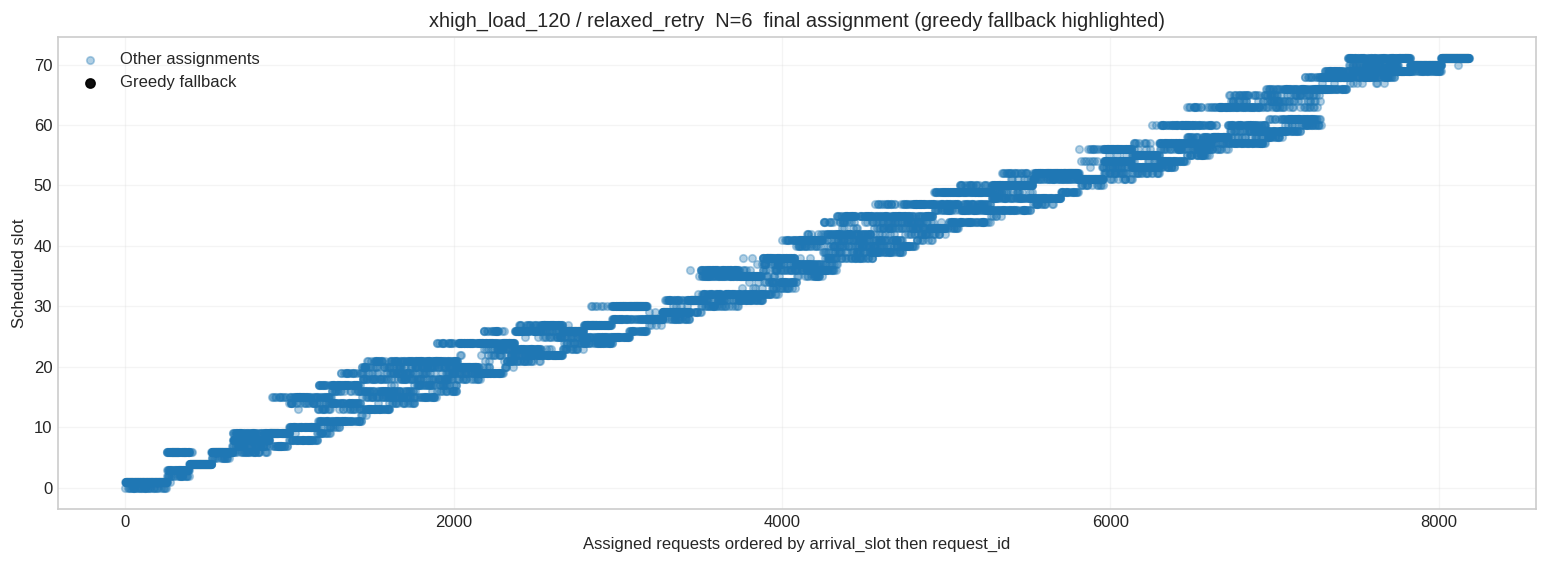

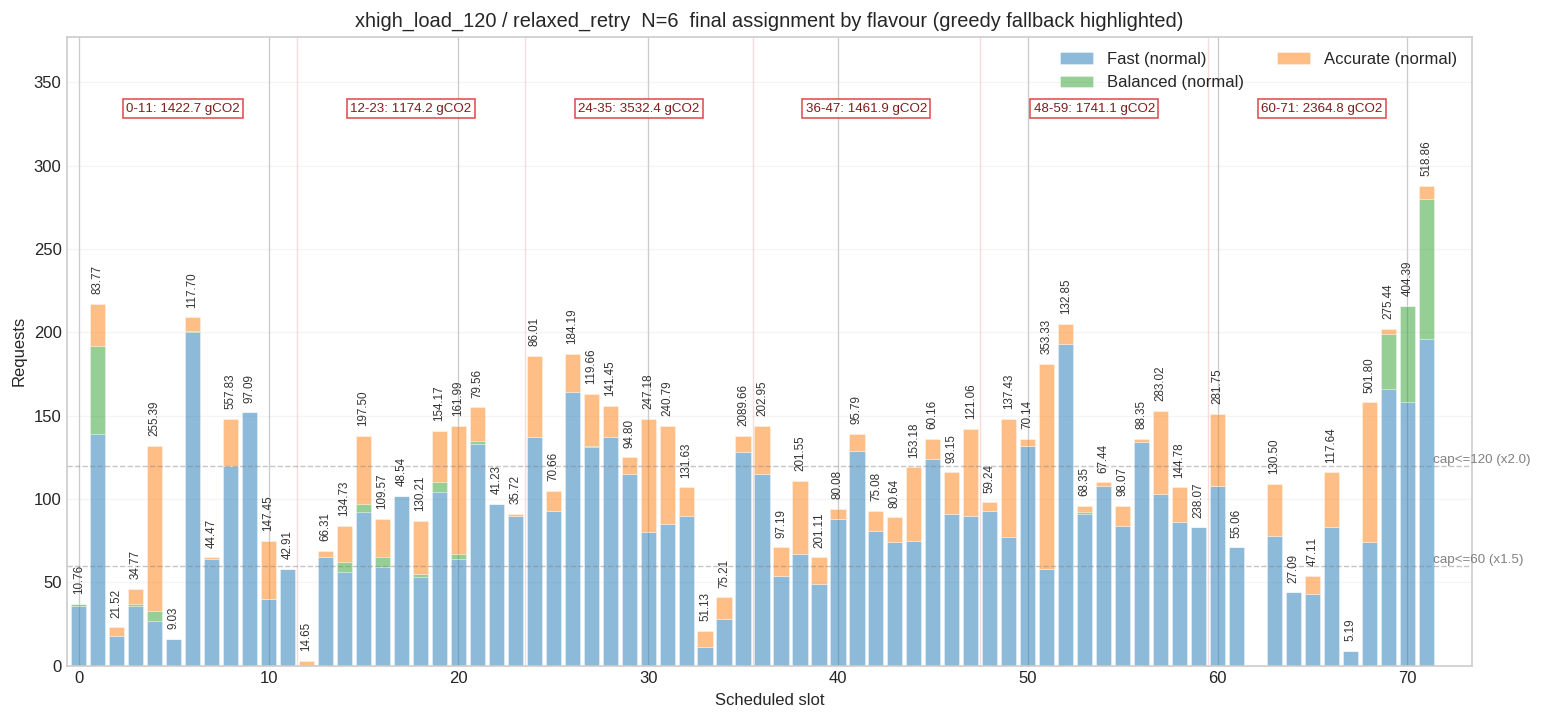

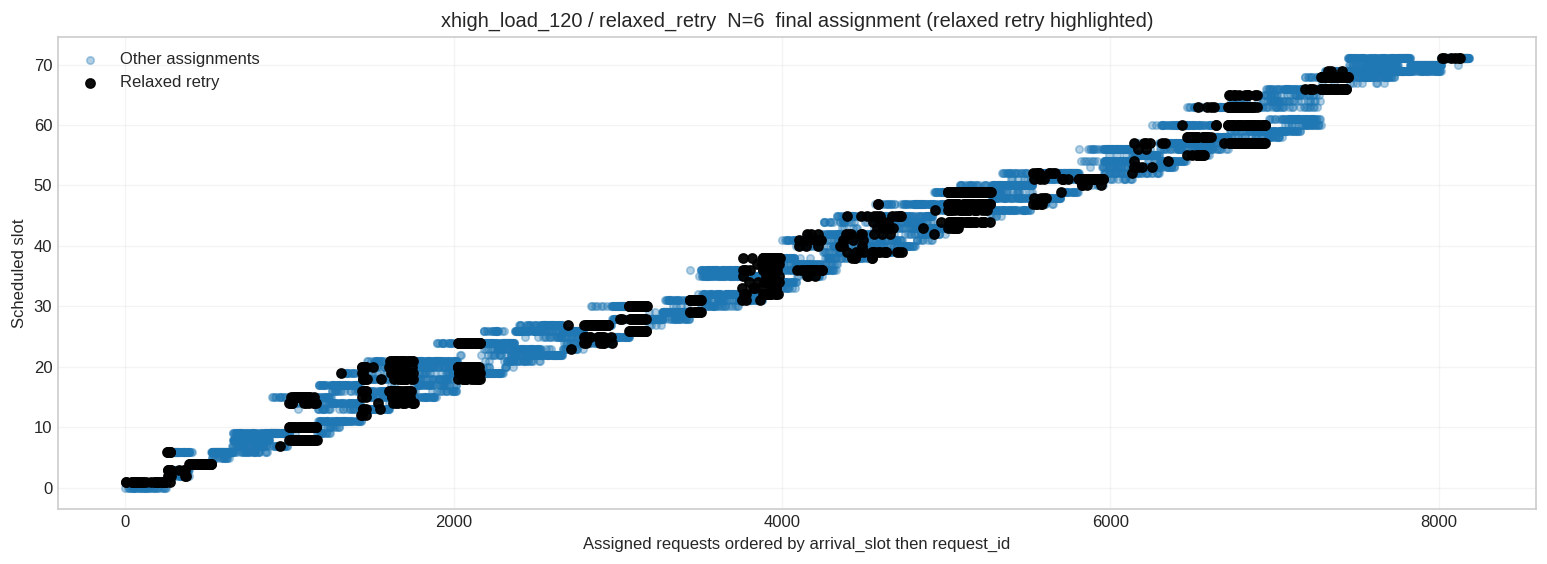

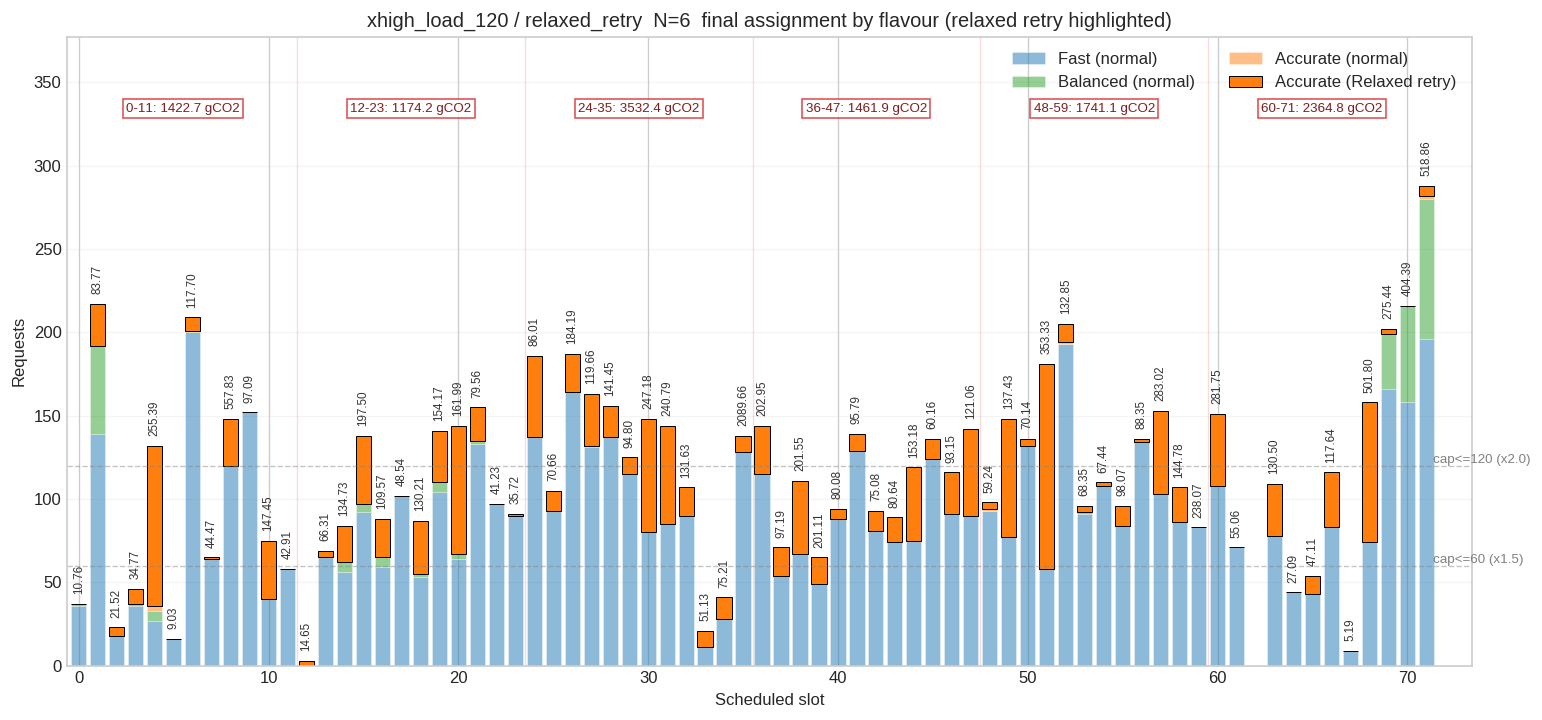

In [57]:
# --- final assignment only: no per-run animation, just the end state ---
timeline_df = _prepare_timeline(per_request)

_plot_timeline(
    timeline_df,
    flag_col="assigned_with_greedy_fallback",
    title_scatter=f"{scenario_id} / {mode_label}  N={SELECTED_N}  final assignment (greedy fallback highlighted)",
    title_stacked=f"{scenario_id} / {mode_label}  N={SELECTED_N}  final assignment by flavour (greedy fallback highlighted)",
    dark_label="Greedy fallback",
)

_plot_timeline(
    timeline_df,
    flag_col="assigned_with_relaxed_retry",
    title_scatter=f"{scenario_id} / {mode_label}  N={SELECTED_N}  final assignment (relaxed retry highlighted)",
    title_stacked=f"{scenario_id} / {mode_label}  N={SELECTED_N}  final assignment by flavour (relaxed retry highlighted)",
    dark_label="Relaxed retry",
)